In [1]:
pip install pandas numpy matplotlib seaborn jupyter


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

train_transaction = pd.read_csv("../data/train_transaction.csv")
train_identity = pd.read_csv("../data/train_identity.csv")

train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(train_transaction.shape)
print(train_identity.shape)

(590540, 394)
(144233, 41)


In [4]:
train_transaction.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train_transaction["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [6]:
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [7]:
train_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [8]:
train_transaction.isnull().sum().sort_values(ascending=False).head(20)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
D6       517353
D9       515614
D8       515614
V153     508595
V139     508595
V162     508595
V161     508595
V154     508595
V138     508595
V158     508595
V157     508595
V163     508595
V156     508595
V155     508595
V149     508595
dtype: int64

In [9]:
print(train_transaction.shape)
print(train_identity.shape)

(590540, 394)
(144233, 41)


In [10]:
train_transaction.columns[:20]


Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3'],
      dtype='object')

In [11]:
train_transaction["isFraud"].value_counts()
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [12]:
train_transaction["TransactionAmt"].describe()


count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [13]:
train_transaction[["TransactionAmt","isFraud"]].groupby("isFraud").describe()

TransactionAmt                                                      \
                 count        mean         std    min     25%   50%    75%   
isFraud                                                                      
0             569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1              20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

                    
               max  
isFraud             
0        31937.391  
1         5191.000

In [14]:
import matplotlib.pyplot as plt
import numpy as np

print(np.__version__)

1.26.4


<Axes: >

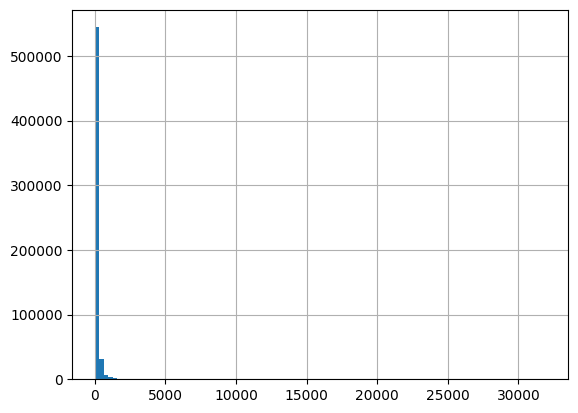

In [15]:
train_transaction["TransactionAmt"].hist(bins=100)

In [16]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [17]:
import matplotlib
import matplotlib.pyplot as plt

print(matplotlib.__version__)

3.8.4


<Axes: >

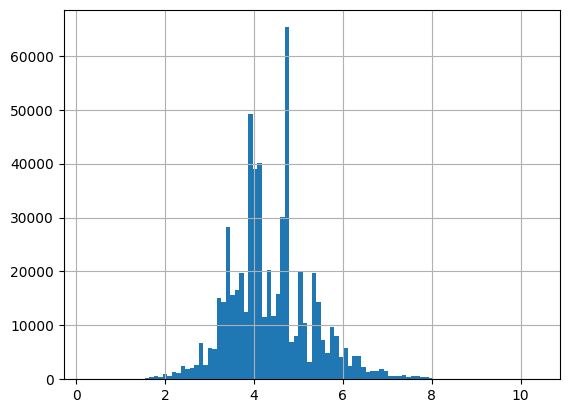

In [18]:
import numpy as np

np.log1p(train_transaction["TransactionAmt"]).hist(bins=100)

In [19]:
train_transaction.groupby("isFraud")["TransactionAmt"].median()


isFraud
0    68.5
1    75.0
Name: TransactionAmt, dtype: float64

In [20]:
train_transaction.groupby("isFraud")["TransactionAmt"].mean()


isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

In [21]:
train_transaction["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

In [22]:
pd.crosstab(
    train_transaction["ProductCD"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
ProductCD,,
C,88.312731,11.687269
H,95.233769,4.766231
R,96.217406,3.782594
S,94.100447,5.899553
W,97.960061,2.039939


In [23]:
train_transaction["card4"].value_counts()

card4
visa                384767
mastercard          189217
american express      8328
discover              6651
Name: count, dtype: int64

In [24]:
pd.crosstab(
    train_transaction["card4"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
card4,,
american express,97.130163,2.869837
discover,92.271839,7.728161
mastercard,96.566905,3.433095
visa,96.524390,3.475610


In [25]:
pd.crosstab(
    train_transaction["P_emaildomain"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
P_emaildomain,,
aim.com,87.301587,12.698413
anonymous.com,97.678253,2.321747
aol.com,97.818940,2.181060
att.net,99.256137,0.743863
bellsouth.net,97.223677,2.776323
cableone.net,98.113208,1.886792
centurylink.net,100.000000,0.000000
cfl.rr.com,100.000000,0.000000
charter.net,96.936275,3.063725


In [26]:
train_transaction["P_emaildomain"].value_counts().head(20)

P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
live.com           3041
sbcglobal.net      2970
verizon.net        2705
ymail.com          2396
bellsouth.net      1909
yahoo.com.mx       1543
me.com             1522
cox.net            1393
optonline.net      1011
charter.net         816
Name: count, dtype: int64

In [27]:
train_transaction["P_emaildomain"].value_counts().loc[
    ["protonmail.com","mail.com","outlook.com"]
]

P_emaildomain
protonmail.com      76
mail.com           559
outlook.com       5096
Name: count, dtype: int64

In [28]:
pd.crosstab(
    train_transaction["card6"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
card6,,
charge card,100.000000,0.000000
credit,93.321520,6.678480
debit,97.573749,2.426251
debit or credit,100.000000,0.000000


In [29]:
pd.crosstab(
    pd.cut(train_transaction["dist1"], bins=10),
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
dist1,,
"(-10.286, 1028.6]",98.023631,1.976369
"(1028.6, 2057.2]",97.454948,2.545052
"(2057.2, 3085.8]",97.584541,2.415459
"(3085.8, 4114.4]",96.850394,3.149606
"(4114.4, 5143.0]",98.347107,1.652893
"(5143.0, 6171.6]",100.000000,0.000000
"(6171.6, 7200.2]",100.000000,0.000000
"(7200.2, 8228.8]",100.000000,0.000000
"(9257.4, 10286.0]",100.000000,0.000000


In [30]:
train_transaction.groupby("isFraud")["TransactionDT"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,7.360791e+06,4.623930e+06,86400.0,3010651.0,7271678.0,11253338.0,15811131.0
1,20663.0,7.690033e+06,4.416551e+06,89760.0,3965858.0,7575230.0,11217428.0,15810876.0


In [31]:
pd.crosstab(
    train_transaction["P_emaildomain"],
    train_transaction["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
P_emaildomain,,
aim.com,87.301587,12.698413
anonymous.com,97.678253,2.321747
aol.com,97.818940,2.181060
att.net,99.256137,0.743863
bellsouth.net,97.223677,2.776323
cableone.net,98.113208,1.886792
centurylink.net,100.000000,0.000000
cfl.rr.com,100.000000,0.000000
charter.net,96.936275,3.063725


In [32]:
merged = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

In [33]:
pd.crosstab(
    merged["DeviceType"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
DeviceType,,
desktop,93.478542,6.521458
mobile,89.833768,10.166232


In [34]:
merged.shape

(590540, 434)

In [35]:
pd.crosstab(
    merged["DeviceInfo"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
DeviceInfo,,
0PAJ5,100.0,0.0
0PJA2,100.0,0.0
0PM92,50.0,50.0
1016S,100.0,0.0
2PQ93,100.0,0.0
...,...,...
verykools5004,100.0,0.0
verykools5034,100.0,0.0
verykools5035,100.0,0.0


In [36]:
merged["DeviceInfo"].value_counts().head(20)

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64

In [37]:
pd.crosstab(
    merged["id_30"],
    merged["isFraud"],
    normalize="index"
) * 100

isFraud,0,1
id_30,,
Android,89.434662,10.565338
Android 4.4.2,74.603175,25.396825
Android 5.0,100.000000,0.000000
Android 5.0.2,100.000000,0.000000
Android 5.1.1,71.142857,28.857143
...,...,...
iOS 11.3.1,97.794118,2.205882
iOS 11.4.0,80.000000,20.000000
iOS 11.4.1,100.000000,0.000000


In [38]:
device_stats = pd.crosstab(
    merged["id_30"],
    merged["isFraud"]
)

device_stats["FraudRate"] = (
    device_stats[1] /
    (device_stats[0] + device_stats[1])
) * 100

device_stats["TotalCount"] = (
    device_stats[0] + device_stats[1]
)

device_stats.sort_values(
    by="FraudRate",
    ascending=False
)

isFraud,0,1,FraudRate,TotalCount
id_30,,,,
other,6,9,60.000000,15
Android 5.1.1,249,101,28.857143,350
Android 4.4.2,47,16,25.396825,63
iOS 11.4.0,4,1,20.000000,5
iOS 11.0.1,102,25,19.685039,127
...,...,...,...,...
Mac OS X 10_13_5,4,0,0.000000,4
Mac OS X 10_7_5,93,0,0.000000,93
Mac OS X 10_8_5,74,0,0.000000,74


In [39]:
device_info_stats = pd.crosstab(
    merged["DeviceInfo"],
    merged["isFraud"]
)

device_info_stats["FraudRate"] = (
    device_info_stats[1] /
    (device_info_stats[0] + device_info_stats[1])
) * 100

device_info_stats["TotalCount"] = (
    device_info_stats[0] + device_info_stats[1]
)

device_info_stats[
    device_info_stats["TotalCount"] >= 100
].sort_values(
    by="FraudRate",
    ascending=False
).head(20)

isFraud,0,1,FraudRate,TotalCount
DeviceInfo,,,,
hi6210sft Build/MRA58K,10,180,94.736842,190
SM-A300H Build/LRX22G,34,169,83.251232,203
SM-J320M Build/LMY47V,114,57,33.333333,171
WAS-LX3 Build/HUAWEIWAS-LX3,80,28,25.925926,108
Moto Z2 Play Build/NPSS26.118-19-14,99,30,23.255814,129
Moto E (4) Plus Build/NMA26.42-69,128,32,20.000000,160
SM-J701M Build/NRD90M,124,30,19.480519,154
SM-G955F Build/NRD90M,108,26,19.402985,134
Moto E (4) Build/NMA26.42-69,102,23,18.400000,125


In [40]:
device_info_stats = pd.crosstab(
    merged["id_31"],
    merged["isFraud"]
)

device_info_stats["FraudRate"] = (
    device_info_stats[1] /
    (device_info_stats[0] + device_info_stats[1])
) * 100

device_info_stats["TotalCount"] = (
    device_info_stats[0] + device_info_stats[1]
)

device_info_stats[
    device_info_stats["TotalCount"] >= 100
].sort_values(
    by="FraudRate",
    ascending=False
).head(20)

isFraud,0,1,FraudRate,TotalCount
id_31,,,,
chrome 52.0 for android,94,58,38.157895,152
opera 49.0,95,43,31.159420,138
chrome 58.0,137,51,27.127660,188
chrome 50.0 for android,107,38,26.206897,145
android webview 4.0,216,69,24.210526,285
firefox,526,147,21.842496,673
other,251,61,19.551282,312
chrome 58.0 for android,212,50,19.083969,262
chrome 56.0 for android,194,44,18.487395,238


In [41]:
for col in ["addr1", "addr2"]:
    stats = pd.crosstab(
        train_transaction[col],
        train_transaction["isFraud"]
    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100
    stats["TotalCount"] = stats[0] + stats[1]

    display(
        stats[stats["TotalCount"] >= 100]
        .sort_values("FraudRate", ascending=False)
        .head(20)
    )

isFraud,0,1,FraudRate,TotalCount
addr1,,,,
296.0,289,78,21.253406,367
161.0,339,82,19.477435,421
536.0,259,50,16.181230,309
130.0,313,29,8.479532,342
465.0,461,42,8.349901,503
122.0,1500,117,7.235622,1617
308.0,1196,83,6.489445,1279
511.0,147,10,6.369427,157
324.0,2061,112,5.154165,2173


isFraud,0,1,FraudRate,TotalCount
addr2,,,,
96.0,549,89,13.949843,638
60.0,2805,279,9.046693,3084
87.0,508004,12477,2.397206,520481


In [42]:
for col in ["M4", "M6"]:
    stats = pd.crosstab(

        train_transaction[col],

        train_transaction["isFraud"]

    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100

    stats["TotalCount"] = stats[0] + stats[1]

    display(

        stats[stats["TotalCount"] >= 100]

        .sort_values("FraudRate", ascending=False)

        .head(20)

    )

isFraud,0,1,FraudRate,TotalCount
M4,,,,
M2,53056,6809,11.373925,59865
M0,189207,7198,3.664876,196405
M1,51397,1429,2.705107,52826


isFraud,0,1,FraudRate,TotalCount
M6,,,,
F,222459,5397,2.368601,227856
T,190029,3295,1.704393,193324


In [43]:
for col in ["M1","M2","M3","M5","M7","M8","M9"]:

    stats = pd.crosstab(

        train_transaction[col],

        train_transaction["isFraud"]

    )

    stats["FraudRate"] = stats[1] / (stats[0] + stats[1]) * 100

    stats["TotalCount"] = stats[0] + stats[1]

    display(

        stats[stats["TotalCount"] >= 100]

        .sort_values("FraudRate", ascending=False)

        .head(20)

    )

isFraud,0,1,FraudRate,TotalCount
M1,,,,
T,313073,6342,1.985505,319415


isFraud,0,1,FraudRate,TotalCount
M2,,,,
F,32788,1184,3.485223,33972
T,280310,5158,1.806858,285468


isFraud,0,1,FraudRate,TotalCount
M3,,,,
F,65660,2049,3.026186,67709
T,247438,4293,1.705392,251731


isFraud,0,1,FraudRate,TotalCount
M5,,,,
T,103512,4055,3.769744,107567
F,128977,3514,2.652256,132491


isFraud,0,1,FraudRate,TotalCount
M7,,,,
T,32173,728,2.212699,32901
F,207285,4089,1.934486,211374


isFraud,0,1,FraudRate,TotalCount
M8,,,,
F,151878,3373,2.172611,155251
T,87593,1444,1.621798,89037


isFraud,0,1,FraudRate,TotalCount
M9,,,,
F,37473,1159,3.000104,38632
T,201998,3658,1.778698,205656


In [44]:
train_transaction.groupby("isFraud")[
    ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"]
].mean()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10
isFraud,,,,,,,,,,
0,13.314952,14.173283,0.005840,3.693878,5.722537,8.786377,2.517484,4.560881,4.580904,4.723526
1,35.535740,45.509413,0.000242,15.077336,1.406717,16.923148,11.977157,21.242608,1.703964,19.493926


In [45]:
for col in ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"]:
    print("\n", col)
    print(train_transaction.groupby("isFraud")[col].median())


 C1
isFraud
0    1.0
1    2.0
Name: C1, dtype: float64

 C2
isFraud
0    1.0
1    2.0
Name: C2, dtype: float64

 C3
isFraud
0    0.0
1    0.0
Name: C3, dtype: float64

 C4
isFraud
0    0.0
1    1.0
Name: C4, dtype: float64

 C5
isFraud
0    0.0
1    0.0
Name: C5, dtype: float64

 C6
isFraud
0    1.0
1    1.0
Name: C6, dtype: float64

 C7
isFraud
0    0.0
1    0.0
Name: C7, dtype: float64

 C8
isFraud
0    0.0
1    1.0
Name: C8, dtype: float64

 C9
isFraud
0    1.0
1    0.0
Name: C9, dtype: float64

 C10
isFraud
0    0.0
1    1.0
Name: C10, dtype: float64


In [46]:
train_transaction[[
    "TransactionAmt",
    "C1","C2","C4","C8","C10",
    "isFraud"
]].corr(numeric_only=True)["isFraud"].sort_values(ascending=False)

isFraud           1.000000
C2                0.037229
C8                0.032139
C1                0.030570
C4                0.030382
C10               0.028396
TransactionAmt    0.011320
Name: isFraud, dtype: float64

In [47]:
corr = train_transaction.corr(numeric_only=True)["isFraud"]
corr.sort_values(ascending=False).head(20)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64

In [48]:
for col in ["V257","V246","V244","V242","V201"]:
    print("\n", col)
    print(train_transaction.groupby("isFraud")[col].describe()[["mean","50%"]])


 V257
             mean  50%
isFraud               
0        1.106015  1.0
1        2.961342  2.0

 V246
             mean  50%
isFraud               
0        1.072598  1.0
1        2.494702  1.0

 V244
             mean  50%
isFraud               
0        1.044478  1.0
1        1.992543  1.0

 V242
             mean  50%
isFraud               
0        1.044162  1.0
1        1.931024  1.0

 V201
             mean  50%
isFraud               
0        1.022664  1.0
1        2.745980  1.0


In [49]:
train_transaction[[
    "TransactionAmt",
    "V257",
    "V246",
    "V244",
    "V242",
    "isFraud"
]].corr(numeric_only=True)

,TransactionAmt,V257,V246,V244,V242,isFraud
TransactionAmt,1.000000,-0.009878,-0.017490,-0.013688,-0.004766,0.011320
V257,-0.009878,1.000000,0.905762,0.757727,0.753764,0.383060
V246,-0.017490,0.905762,1.000000,0.829339,0.826648,0.366878
V244,-0.013688,0.757727,0.829339,1.000000,0.974318,0.364129
V242,-0.004766,0.753764,0.826648,0.974318,1.000000,0.360590
isFraud,0.011320,0.383060,0.366878,0.364129,0.360590,1.000000


In [50]:
for col in ["V257","V246","V244","V242","V201"]:
    print("\n", col)
    print(train_transaction[col].describe())


 V257
count    130430.000000
mean          1.250993
std           1.299956
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          48.000000
Name: V257, dtype: float64

 V246
count    130430.000000
mean          1.183723
std           1.040363
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          45.000000
Name: V246, dtype: float64

 V244
count    130430.000000
mean          1.118562
std           0.698807
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          22.000000
Name: V244, dtype: float64

 V242
count    130430.000000
mean          1.113463
std           0.660110
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          20.000000
Name: V242, dtype: float64

 V201
count    139819.000000
mean          1.159106
std           1.418618
min           0.000000
25%           1.000000
50%   

In [51]:
train_transaction[
    ["TransactionAmt","V257","V246","V244","V242","V201"]
].corr()

,TransactionAmt,V257,V246,V244,V242,V201
TransactionAmt,1.000000,-0.009878,-0.017490,-0.013688,-0.004766,-0.000919
V257,-0.009878,1.000000,0.905762,0.757727,0.753764,0.732820
V246,-0.017490,0.905762,1.000000,0.829339,0.826648,0.674866
V244,-0.013688,0.757727,0.829339,1.000000,0.974318,0.537285
V242,-0.004766,0.753764,0.826648,0.974318,1.000000,0.532819
V201,-0.000919,0.732820,0.674866,0.537285,0.532819,1.000000


In [52]:
corr_with_fraud = train_transaction.corr(
    numeric_only=True
)["isFraud"].abs().sort_values(ascending=False)

corr_with_fraud.head(30)


isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
Name: isFraud, dtype: float64

In [53]:
top_v = [
    "V257","V246","V244","V242",
    "V201","V200","V189","V188","V258"
]

train_transaction.groupby("isFraud")[top_v].median().T

isFraud,0,1
V257,1.0,2.0
V246,1.0,1.0
V244,1.0,1.0
V242,1.0,1.0
V201,1.0,1.0
V200,1.0,1.0
V189,1.0,1.0
V188,1.0,1.0
V258,1.0,2.0


In [54]:
for col in ["V246","V244","V242","V201","V200"]:
    print(col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )

V246
isFraud          0          1
V246                         
False    97.237063   2.762937
True     57.892831  42.107169
V244
isFraud          0          1
V244                         
False    97.129059   2.870941
True     49.815027  50.184973
V242
isFraud          0          1
V242                         
False    97.114240   2.885760
True     50.578258  49.421742
V201
isFraud          0          1
V201                         
False    97.289808   2.710192
True     63.602835  36.397165
V200
isFraud          0          1
V200                         
False    97.238327   2.761673
True     62.055591  37.944409


In [55]:
top_v = [
    "V242","V244","V246","V257","V258"
]

train_transaction[top_v].corr()

,V242,V244,V246,V257,V258
V242,1.000000,0.974318,0.826648,0.753764,0.710043
V244,0.974318,1.000000,0.829339,0.757727,0.710709
V246,0.826648,0.829339,1.000000,0.905762,0.740122
V257,0.753764,0.757727,0.905762,1.000000,0.779436
V258,0.710043,0.710709,0.740122,0.779436,1.000000


In [56]:
for col in ["V242","V244","V246","V257","V258"]:
    print("\n", col)
    print(train_transaction[col].isna().mean()*100)


 V242
77.91343516103905

 V244
77.91343516103905

 V246
77.91343516103905

 V257
77.91343516103905

 V258
77.91343516103905


In [57]:
train_transaction[
    ["V242","V244","V246","V257","V258"]
].isna().corr()

,V242,V244,V246,V257,V258
V242,1.0,1.0,1.0,1.0,1.0
V244,1.0,1.0,1.0,1.0,1.0
V246,1.0,1.0,1.0,1.0,1.0
V257,1.0,1.0,1.0,1.0,1.0
V258,1.0,1.0,1.0,1.0,1.0


In [58]:
top_v = ["V188","V189","V200","V201"]

train_transaction[top_v].corr()

,V188,V189,V200,V201
V188,1.000000,0.899481,0.784486,0.740297
V189,0.899481,1.000000,0.714006,0.801707
V200,0.784486,0.714006,1.000000,0.941582
V201,0.740297,0.801707,0.941582,1.000000


In [59]:
for col in top_v:
    print(col)
    print(train_transaction[col].isna().mean()*100)

V188
76.32353439225116
V189
76.32353439225116
V200
76.32353439225116
V201
76.32353439225116


In [60]:
for col in ["V188","V189","V200","V201"]:
    print("\n", col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )


 V188
isFraud          0          1
V188                         
False    97.039637   2.960363
True     45.619140  54.380860

 V189
isFraud          0          1
V189                         
False    97.091846   2.908154
True     47.788611  52.211389

 V200
isFraud          0          1
V200                         
False    97.238327   2.761673
True     62.055591  37.944409

 V201
isFraud          0          1
V201                         
False    97.289808   2.710192
True     63.602835  36.397165


In [61]:
train_transaction[
    ["V188","V189","V200","V201",
     "V242","V244","V246","V257","V258"]
].corr()

,V188,V189,V200,V201,V242,V244,V246,V257,V258
V188,1.000000,0.899481,0.784486,0.740297,0.633283,0.655513,0.574379,0.519819,0.441904
V189,0.899481,1.000000,0.714006,0.801707,0.645411,0.664891,0.573490,0.516381,0.461633
V200,0.784486,0.714006,1.000000,0.941582,0.525953,0.530639,0.680426,0.747843,0.627006
V201,0.740297,0.801707,0.941582,1.000000,0.532819,0.537285,0.674866,0.732820,0.637254
V242,0.633283,0.645411,0.525953,0.532819,1.000000,0.974318,0.826648,0.753764,0.710043
V244,0.655513,0.664891,0.530639,0.537285,0.974318,1.000000,0.829339,0.757727,0.710709
V246,0.574379,0.573490,0.680426,0.674866,0.826648,0.829339,1.000000,0.905762,0.740122
V257,0.519819,0.516381,0.747843,0.732820,0.753764,0.757727,0.905762,1.000000,0.779436
V258,0.441904,0.461633,0.627006,0.637254,0.710043,0.710709,0.740122,0.779436,1.000000


In [62]:
for col in ["V188","V189","V200","V201",
            "V242","V244","V246","V257","V258"]:
    print(col, train_transaction[col].isna().mean()*100)

V188 76.32353439225116
V189 76.32353439225116
V200 76.32353439225116
V201 76.32353439225116
V242 77.91343516103905
V244 77.91343516103905
V246 77.91343516103905
V257 77.91343516103905
V258 77.91343516103905


In [63]:
nan_pct = train_transaction[
    [f"V{i}" for i in range(1,340)]
].isna().mean()*100

nan_pct.value_counts().sort_index()

0.002032     32
0.053172     43
0.214888     11
12.881939    23
13.055170    22
15.098723    20
28.612626    18
47.293494    11
76.053104    16
76.323534    19
76.355370    31
77.913435    46
86.054967    18
86.122701    11
86.123717    18
Name: count, dtype: int64

In [64]:
v_cols = [f"V{i}" for i in range(1,340)]

corr = train_transaction[
    ["isFraud"] + v_cols
].corr(numeric_only=True)["isFraud"]

corr.abs().sort_values(ascending=False).head(50)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
V154       0.206958
V190       0.205148
V39        0.203097
V38        0.199005
V146       0.198584
V43        0.198274
V140       0.196938
V79        0.194141
V42        0.189428
V94        0.188407
V74        0.185915
V33        0.183486
V153       0.183114
V17        0.182673
V18        0.182550
V81        0.182377
V93        0.180983
V92        0.180513
V34        0.180301
V80        0.180299


In [65]:
for col in ["V188","V189","V200","V201",
            "V242","V244","V246","V257","V258"]:
    print("\n", col)
    print(
        train_transaction[col]
        .value_counts(dropna=False)
        .head(10)
    )


 V188
V188
NaN     450721
1.0     123940
0.0       9693
2.0       4257
3.0        877
4.0        377
5.0        194
6.0        158
7.0        107
11.0        44
Name: count, dtype: int64

 V189
V189
NaN    450721
1.0    123163
0.0      9579
2.0      4656
3.0      1067
4.0       442
5.0       240
7.0       134
6.0       121
8.0        96
Name: count, dtype: int64

 V200
V200
NaN    450721
1.0    117750
0.0      9693
2.0      8523
3.0      1723
4.0       728
5.0       366
6.0       293
7.0       161
9.0       105
Name: count, dtype: int64

 V201
V201
NaN    450721
1.0    116412
0.0      9579
2.0      9285
3.0      1922
4.0       860
5.0       422
6.0       270
7.0       186
9.0       178
Name: count, dtype: int64

 V242
V242
NaN    460110
1.0    122640
2.0      5218
3.0      1164
4.0       480
5.0       281
6.0       195
7.0       150
8.0        89
9.0        60
Name: count, dtype: int64

 V244
V244
NaN    460110
1.0    122583
2.0      5139
3.0      1223
4.0       481
5.0       305
6.0 

In [66]:
for col in [
    "V147","V148","V149",
    "V154","V155","V156","V157","V158"
]:
    print(col,
          train_transaction[col].isna().mean()*100)

V147 86.12371727571374
V148 86.12371727571374
V149 86.12371727571374
V154 86.12371727571374
V155 86.12371727571374
V156 86.12371727571374
V157 86.12371727571374
V158 86.12371727571374


In [67]:
train_transaction[
    ["V147","V148","V149",
     "V154","V155","V156","V157","V158"]
].corr()

,V147,V148,V149,V154,V155,V156,V157,V158
V147,1.000000,0.415549,0.487752,0.390094,0.433787,0.501809,0.485167,0.552602
V148,0.415549,1.000000,0.950232,0.939466,0.975978,0.931158,0.916441,0.876240
V149,0.487752,0.950232,1.000000,0.915597,0.926838,0.976168,0.870524,0.918618
V154,0.390094,0.939466,0.915597,1.000000,0.949000,0.929691,0.879524,0.861917
V155,0.433787,0.975978,0.926838,0.949000,1.000000,0.953647,0.924755,0.883433
V156,0.501809,0.931158,0.976168,0.929691,0.953647,1.000000,0.881782,0.925047
V157,0.485167,0.916441,0.870524,0.879524,0.924755,0.881782,1.000000,0.954520
V158,0.552602,0.876240,0.918618,0.861917,0.883433,0.925047,0.954520,1.000000


In [68]:
for v in ["V39","V40","V42","V43","V44","V45"]:
    print(v, train_transaction[v].isna().mean()*100)

V39 28.612625732380533
V40 28.612625732380533
V42 28.612625732380533
V43 28.612625732380533
V44 28.612625732380533
V45 28.612625732380533


In [69]:
train_transaction[
    ["V39","V40","V42","V43","V44","V45"]
].corr()

,V39,V40,V42,V43,V44,V45
V39,1.000000,0.943888,0.876143,0.834217,0.228998,0.224568
V40,0.943888,1.000000,0.832790,0.853337,0.216561,0.260687
V42,0.876143,0.832790,1.000000,0.952002,0.166695,0.171445
V43,0.834217,0.853337,0.952002,1.000000,0.162832,0.211239
V44,0.228998,0.216561,0.166695,0.162832,1.000000,0.905101
V45,0.224568,0.260687,0.171445,0.211239,0.905101,1.000000


In [70]:
for col in [
    "V39","V40","V42","V43","V44","V45"
]:
    print("\n", col)
    print(
        pd.crosstab(
            train_transaction[col] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )


 V39
isFraud          0          1
V39                          
False    96.680094   3.319906
True     67.751641  32.248359

 V40
isFraud          0          1
V40                          
False    96.769523   3.230477
True     71.442262  28.557738

 V42
isFraud          0          1
V42                          
False    96.590498   3.409502
True     73.916774  26.083226

 V43
isFraud          0          1
V43                          
False    96.696447   3.303553
True     78.608369  21.391631

 V44
isFraud          0          1
V44                          
False    97.094679   2.905321
True     82.161264  17.838736

 V45
isFraud          0          1
V45                          
False    97.172219   2.827781
True     85.559006  14.440994


In [71]:
for v in ["V86","V87"]:
    print(v, train_transaction[v].isna().mean()*100)

train_transaction[
    ["V86","V87"]
].corr()

V86 15.098723202492634
V87 15.098723202492634


,V86,V87
V86,1.000000,0.849442
V87,0.849442,1.000000


In [72]:
for v in ["V170","V171"]:
    print(v, train_transaction[v].isna().mean()*100)

train_transaction[
    ["V170","V171"]
].corr()

V170 76.32353439225116
V171 76.32353439225116


,V170,V171
V170,1.000000,0.767816
V171,0.767816,1.000000


In [73]:
for v in ["V170","V171"]:
    print(v)
    print(
        pd.crosstab(
            train_transaction[v] > 1,
            train_transaction["isFraud"],
            normalize="index"
        ) * 100
    )

V170
isFraud          0          1
V170                         
False    97.323477   2.676523
True     80.350840  19.649160
V171


isFraud          0          1
V171                         
False    97.382242   2.617758
True     81.811382  18.188618


In [74]:
missing = train_transaction.isnull().mean()*100

print("80%+ missing:", (missing > 80).sum())
print("50-80% missing:", ((missing > 50) & (missing <= 80)).sum())
print("20-50% missing:", ((missing > 20) & (missing <= 50)).sum())

80%+ missing: 55
50-80% missing: 119
20-50% missing: 38


In [75]:
train_transaction["isFraud"].value_counts(normalize=True)*100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [76]:
train_transaction["TransactionDT"].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

<Axes: >

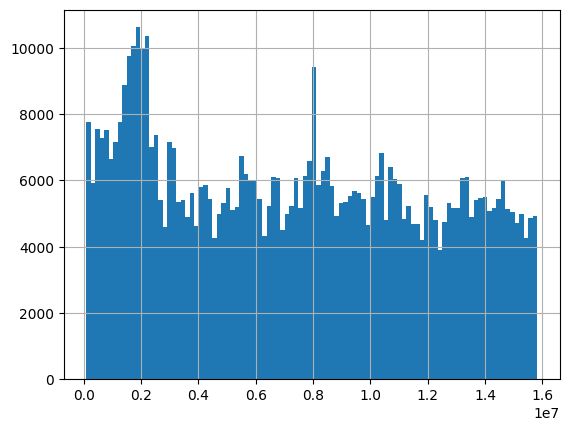

In [77]:
train_transaction["TransactionDT"].hist(bins=100)

In [78]:
# Merge transaction + identity first
train = train_transaction.merge(train_identity, on='TransactionID', how='left')

# Now split by time yourself
threshold = train['TransactionDT'].quantile(0.80)
X_train = train[train['TransactionDT'] < threshold]
X_val   = train[train['TransactionDT'] >= threshold]

In [79]:
print(train.shape)
print(X_train.shape)
print(X_val.shape)
print(X_train['isFraud'].mean())
print(X_val['isFraud'].mean())

(590540, 434)
(472432, 434)
(118108, 434)
0.03513521522674162
0.034409184813899145


In [80]:
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

In [81]:
features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6"
]

In [82]:
for col in ["ProductCD","card4","card6"]:
    train[col] = train[col].astype("category")

X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [83]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 271
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [84]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [85]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.1402794115739693


In [86]:
features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",

    "DeviceType",
    "id_30",
    "id_31",

    "P_emaildomain",
    "R_emaildomain",

    "addr1",
    "addr2",

    "M4",
    "M6"
]

for col in features:
    if train[col].dtype == "object":
        train[col] = train[col].astype("category")

In [87]:


X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [88]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 740
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [89]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [90]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.19949041390926203


In [91]:
features += [
    "V188",
    "V189",
    "V200",
    "V201",

    "V242",
    "V244",
    "V246",
    "V257",
    "V258"
]


In [92]:


X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [93]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 984
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [94]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [95]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.3827499096991183


In [96]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(20))

           feature  importance
0   TransactionAmt        1203
9            addr1        1032
6            id_31         703
7    P_emaildomain         628
5            id_30         401
11              M4         343
8    R_emaildomain         268
12              M6         193
2            card4         144
14            V189         139
10           addr2         130
21            V258         125
1        ProductCD         114
3            card6          98
13            V188          89
15            V200          77
16            V201          74
17            V242          72
20            V257          51
18            V244          46


In [97]:
features += [
    "V147","V148","V149",
    "V154","V155","V156",
    "V157","V158"
]

In [98]:


X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [99]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1083
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [100]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [101]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print(pr_auc)

0.39117510575535547


In [102]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(40))

           feature  importance
0   TransactionAmt        1126
9            addr1         977
6            id_31         681
7    P_emaildomain         650
5            id_30         364
11              M4         324
8    R_emaildomain         253
12              M6         181
2            card4         134
14            V189         134
21            V258         116
1        ProductCD         104
10           addr2         104
3            card6          89
22            V147          73
15            V200          73
16            V201          67
27            V156          67
13            V188          65
17            V242          56
24            V149          54
20            V257          49
25            V154          43
23            V148          40
4       DeviceType          39
29            V158          38
18            V244          32
19            V246          32
28            V157          32
26            V155           3


In [103]:
features += [
    "D1","D2","D3","D4","D5",
    "D10","D11","D15"
]

In [104]:


X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [105]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023883 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [106]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [107]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.43086773099782427


In [108]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(40))

           feature  importance
0   TransactionAmt         619
9            addr1         538
6            id_31         533
7    P_emaildomain         432
31              D2         404
37             D15         383
33              D4         376
5            id_30         279
30              D1         263
35             D10         250
11              M4         242
8    R_emaildomain         212
32              D3         170
36             D11         159
34              D5         112
12              M6         106
1        ProductCD          95
14            V189          85
2            card4          85
10           addr2          77
3            card6          66
21            V258          65
27            V156          53
16            V201          49
22            V147          38
15            V200          38
17            V242          36
24            V149          32
25            V154          28
23            V148          26
13            V188          26
29      

In [109]:
train["MissingCount"] = train.isnull().sum(axis=1)

In [110]:
features += ["MissingCount"]

In [111]:
x_train = train[train["TransactionDT"] < threshold]
x_val   = train[train["TransactionDT"] >= threshold]

In [112]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)
model.fit(
    x_train[features],
    x_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [113]:
print("MissingCount" in X_train.columns)

print(set(features) - set(X_train.columns))

print(features[-10:])

False
{'MissingCount'}
['V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'MissingCount']


In [114]:
X_train.columns[X_train.columns.str.contains("Missing")]

Index([], dtype='object')

In [115]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [116]:
print("MissingCount" in X_train.columns)

True


In [117]:
features = list(dict.fromkeys(features))

In [118]:
features[-10:]

['V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'MissingCount']

In [119]:
print(set(features) - set(X_train.columns))

set()


In [120]:
print("MissingCount" in train.columns)

X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

features = list(dict.fromkeys(features))

print("MissingCount" in X_train.columns)
print(set(features) - set(X_train.columns))

True
True
set()


In [121]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3299
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [122]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [123]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.42656793876972554


In [124]:
features = [f for f in features if f != "MissingCount"]

In [125]:
train["EmailMatch"] = (
    train["P_emaildomain"].astype(str)
    ==
    train["R_emaildomain"].astype(str)
).astype(int)

In [126]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

features.append("EmailMatch")

In [127]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3125
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [128]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [129]:
from sklearn.metrics import average_precision_score

avg_precision = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {avg_precision}")

Average Precision Score: 0.4252274083676712


In [130]:
features = [f for f in features if f != "EmailMatch"]

In [131]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.45352237849046084


In [132]:
scale_pos_weight = (
    len(X_train[X_train["isFraud"] == 0])
    /
    len(X_train[X_train["isFraud"] == 1])
)

print(scale_pos_weight)

27.46147358274595


In [133]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    scale_pos_weight=27.46147358274595,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)

print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3123
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.43569867747122293


In [134]:
features += [
    "C1","C2","C3","C4","C5",
    "C6","C7","C8","C9","C10",
    "C11","C12","C13","C14"
]

In [135]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023413 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6366
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [136]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [137]:
from sklearn.metrics import average_precision_score

ap_score = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {ap_score}")

Average Precision Score: 0.5019102514933917


In [138]:
features += [
    "M1","M2","M3",
    "M5","M7","M8","M9"
]

In [139]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)   

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: M1: object, M2: object, M3: object, M5: object, M7: object, M8: object, M9: object

In [140]:
for col in ["M1","M2","M3","M5","M7","M8","M9"]:
    print(col)
    print(train[col].value_counts(dropna=False).head())
    print()

M1
M1
T      319415
NaN    271100
F          25
Name: count, dtype: int64

M2
M2
T      285468
NaN    271100
F       33972
Name: count, dtype: int64

M3
M3
NaN    271100
T      251731
F       67709
Name: count, dtype: int64

M5
M5
NaN    350482
F      132491
T      107567
Name: count, dtype: int64

M7
M7
NaN    346265
F      211374
T       32901
Name: count, dtype: int64

M8
M8
NaN    346252
F      155251
T       89037
Name: count, dtype: int64

M9
M9
NaN    346252
T      205656
F       38632
Name: count, dtype: int64



In [141]:
m_cols = ["M1","M2","M3","M5","M7","M8","M9"]

for col in m_cols:
    train[col] = train[col].map({
        "T": 1,
        "F": 0
    })

In [142]:
X_train = train[train["TransactionDT"] < threshold].copy()
X_val   = train[train["TransactionDT"] >= threshold].copy()

In [143]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)   
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030423 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6387
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.05, n_estimators=200, random_state=42)

In [144]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [145]:
from sklearn.metrics import average_precision_score

aps = average_precision_score(X_val["isFraud"], preds)
print(f"Average Precision Score: {aps}")

Average Precision Score: 0.5029880381625598


In [146]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(50))

           feature  importance
6            id_31         485
9            addr1         393
0   TransactionAmt         367
7    P_emaildomain         363
50             C13         259
5            id_30         248
38              C1         246
37             D15         240
31              D2         234
33              D4         221
43              C6         194
30              D1         193
8    R_emaildomain         190
35             D10         186
51             C14         180
46              C9         161
48             C11         151
39              C2         151
32              D3         133
42              C5         119
55              M5         112
36             D11          95
3            card6          86
2            card4          81
11              M4          77
12              M6          71
1        ProductCD          68
49             C12          63
45              C8          53
34              D5          44
21            V258          42
47      

In [147]:
features += [
    "V39","V40","V42",
    "V43","V44","V45"
]

In [148]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6496
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [149]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [150]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5341325042389224


In [151]:
features += [
    "V170",
    "V171"
]

In [152]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6565
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [153]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [154]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5349708779223485


In [155]:
importance = (
    pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

print(importance.head(50))

           feature  importance
9            addr1        2780
0   TransactionAmt        2607
6            id_31        1695
37             D15        1617
50             C13        1476
31              D2        1382
7    P_emaildomain        1328
33              D4        1297
35             D10        1170
30              D1        1072
38              C1         987
39              C2         929
5            id_30         823
43              C6         810
36             D11         691
48             C11         678
51             C14         676
46              C9         628
32              D3         624
55              M5         560
8    R_emaildomain         519
42              C5         474
11              M4         464
12              M6         390
64             V45         341
34              D5         336
45              C8         334
49             C12         295
47             C10         275
2            card4         255
3            card6         218
65      

In [156]:

features += [
    "V46","V47","V48",
    "V49","V50","V51","V52"
]

In [157]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034727 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [158]:
preds = model.predict_proba(
    X_val[features]
)[:,1]  

In [159]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5364760015259026


In [160]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

In [161]:
xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [162]:
from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

XGBoost PR-AUC: 0.5101915449562404


In [163]:
print(len(features))

74


In [164]:
X_train[features].dtypes[
    X_train[features].dtypes == "category"
]

ProductCD        category
card4            category
card6            category
DeviceType       category
id_30            category
id_31            category
P_emaildomain    category
R_emaildomain    category
M4               category
M6               category
dtype: object

In [165]:
X_train_xgb = X_train[features].copy()
X_val_xgb   = X_val[features].copy()

In [166]:
print("MissingCount" in train.columns)
print("MissingCount" in X_train.columns)
print("MissingCount" in X_val.columns)

True
True
True


In [167]:
X_train["MissingCount"] = X_train.isnull().sum(axis=1)
X_val["MissingCount"]   = X_val.isnull().sum(axis=1)

In [168]:
print("MissingCount" in X_train.columns)

True


In [169]:
missing_features = [
    f for f in features
    if f not in X_train.columns
]

print(missing_features)

[]


In [170]:
X_train[['M1','M2','M3','M5','M7','M8','M9']].dtypes

M1    float64
M2    float64
M3    float64
M5    float64
M7    float64
M8    float64
M9    float64
dtype: object

In [171]:
m_cols = ['M1','M2','M3','M5','M7','M8','M9']

for col in m_cols:
    train[col] = train[col].astype('category')

In [172]:
X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [173]:
from sklearn.metrics import average_precision_score

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * lgb_preds +
    0.5 * xgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

ValueError: train and valid dataset categorical_feature do not match.

In [174]:
for v in ["V147","V148","V149"]:
    print(v, train[v].isna().mean()*100)

train[
    ["V147","V148","V149"]
].corr()

V147 86.12371727571374
V148 86.12371727571374
V149 86.12371727571374


,V147,V148,V149
V147,1.000000,0.415549,0.487752
V148,0.415549,1.000000,0.950232
V149,0.487752,0.950232,1.000000


In [175]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    random_state=42
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047989 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, random_state=42)

In [176]:
lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

In [177]:
for col in [
    'ProductCD','card4','card6',
    'DeviceType','id_30','id_31',
    'P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9'
]:
    if str(X_train[col].dtype) == 'category':
        print(
            col,
            len(X_train[col].cat.categories),
            len(X_val[col].cat.categories)
        )

ProductCD 5 5
card4 4 4
card6 4 4
DeviceType 2 2
id_30 75 75
id_31 130 130
P_emaildomain 59 59
R_emaildomain 60 60
M1 2 2
M2 2 2
M3 2 2
M4 3 3
M5 2 2
M6 2 2
M7 2 2
M8 2 2
M9 2 2


In [178]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

Ensemble PR-AUC: 0.5308169379957666


In [179]:
imp = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

imp.head(80)

,feature,importance
9,addr1,1130
0,TransactionAmt,1004
6,id_31,993
7,P_emaildomain,745
50,C13,661
...,...,...
28,V157,16
59,V39,16
71,V50,5
52,M1,3


In [180]:
new_vs = [
    'V46','V47','V48','V49',
    'V50','V51','V52'
]

for v in new_vs:
    if v not in features:
        features.append(v)

In [181]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [182]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [183]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)    

PR-AUC: 0.5362018135278172


In [184]:
import pandas as pd
import numpy as np

# All candidate columns you haven't added yet
candidate_cols = [c for c in X_train.columns 
                  if c not in features 
                  and c not in ['TransactionID','isFraud','TransactionDT']]

# Correlation with fraud for every remaining column
correlations = []
for col in candidate_cols:
    try:
        corr = X_train[col].fillna(-999).corr(X_train['isFraud'])
        null_pct = X_train[col].isnull().mean()
        correlations.append({
            'col': col,
            'corr': abs(corr),
            'null_pct': round(null_pct * 100, 1)
        })
    except:
        pass

corr_df = pd.DataFrame(correlations).sort_values('corr', ascending=False)
print(corr_df[corr_df['corr'] > 0.03].to_string())

              col      corr  null_pct
7              D7  0.154200      93.7
10            D12  0.148324      88.8
12            D14  0.147176      89.5
329         id_10  0.139385      87.0
328         id_09  0.139378      87.0
9              D9  0.139355      87.0
322         id_03  0.135208      88.6
323         id_04  0.135175      88.6
196          V211  0.134060      75.3
6              D6  0.133658      87.6
11            D13  0.133273      89.6
336         id_20  0.132998      75.3
333         id_17  0.131455      75.3
331         id_13  0.131353      77.7
330         id_11  0.130140      75.1
324         id_05  0.129841      75.8
325         id_06  0.129422      75.8
253          V273  0.129001      76.7
195          V210  0.128328      75.3
193          V208  0.128118      75.3
169          V180  0.127816      75.3
174          V185  0.127806      75.3
185          V198  0.127800      75.3
173          V184  0.127794      75.3
184          V197  0.127789      75.3
182         

In [185]:
new_ds = [
    "D6","D7","D8","D9",
    "D12","D13","D14"
]

for col in new_ds:
    if col not in features:
        features.append(col)

In [186]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044698 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8173
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


LGBMClassifier(learning_rate=0.03, n_estimators=500, n_jobs=-1, num_leaves=64,
               random_state=42)

In [187]:
preds = model.predict_proba(
    X_val[features]
)[:,1]

In [188]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5340791465693484


In [189]:
for col in [
    "D6","D7","D8","D9",
    "D12","D13","D14"
]:
    if col in features:
        features.remove(col)

In [190]:
print([c for c in features if c.startswith("D")])

['DeviceType', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15']


In [191]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6618
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 74
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784


In [192]:
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

PR-AUC: 0.5362018135278172


In [193]:
for col in [
    "id_01","id_02",
    "id_03","id_04",
    "id_05","id_06",
    "id_09","id_10",
    "id_11","id_13",
    "id_17","id_20"
]:
    if col not in features:
        features.append(col)

In [194]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037955 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7575
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5395709692111098


In [195]:
new_vs = [
    'V167','V168','V169',
    'V172','V173','V174',
    'V175','V176','V177'
]

for col in new_vs:
    if col not in features:
        features.append(col)

In [196]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7873
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5381501988251064


In [197]:
for col in [
    'V167','V168','V169',
    'V172','V173','V174',
    'V175','V176','V177'
]:
    if col in features:
        features.remove(col)

In [198]:
new_ds = [
    'D6','D7','D8',
    'D9','D12',
    'D13','D14'
]

for col in new_ds:
    if col not in features:
        features.append(col)

In [199]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9130
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5393663797055294


In [200]:
for col in ['D6','D7','D8','D9','D12','D13','D14']:
    if col in features:
        features.remove(col)

In [201]:
imp = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(imp.head(80).to_string())

ValueError: All arrays must be of the same length

In [ ]:
print("features:", len(features))
print("importances:", len(model.feature_importances_))
print(model.n_features_)

features: 86
importances: 93
93


In [202]:
print(model.feature_name_)

['TransactionAmt', 'ProductCD', 'card4', 'card6', 'DeviceType', 'id_30', 'id_31', 'P_emaildomain', 'R_emaildomain', 'addr1', 'addr2', 'M4', 'M6', 'V188', 'V189', 'V200', 'V201', 'V242', 'V244', 'V246', 'V257', 'V258', 'V147', 'V148', 'V149', 'V154', 'V155', 'V156', 'V157', 'V158', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'M1', 'M2', 'M3', 'M5', 'M7', 'M8', 'M9', 'V39', 'V40', 'V42', 'V43', 'V44', 'V45', 'V170', 'V171', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_09', 'id_10', 'id_11', 'id_13', 'id_17', 'id_20', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14']


In [203]:
imp = pd.DataFrame({
    "feature": model.feature_name_,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(imp.head(100).to_string())

           feature  importance
9            addr1        2172
0   TransactionAmt        2031
6            id_31        1618
37             D15        1325
50             C13        1141
31              D2        1110
7    P_emaildomain        1093
33              D4         973
35             D10         935
30              D1         917
38              C1         905
85           id_20         877
88              D8         786
5            id_30         752
43              C6         717
39              C2         704
75           id_02         613
48             C11         577
51             C14         568
46              C9         561
36             D11         552
32              D3         521
8    R_emaildomain         442
79           id_06         419
74           id_01         402
83           id_13         384
92             D14         381
78           id_05         374
11              M4         367
42              C5         365
55              M5         356
12      

In [204]:
remaining_ids = [
    c for c in X_train.columns
    if c.startswith("id_")
    and c not in features
]

print(remaining_ids)

['id_07', 'id_08', 'id_12', 'id_14', 'id_15', 'id_16', 'id_18', 'id_19', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [205]:
remaining_d = [
    c for c in X_train.columns
    if c.startswith("D")
    and c not in features
]

print(remaining_d)

['D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'DeviceInfo']


In [206]:
print(len(features))
print("D14" in features)
print("D13" in features)
print("D12" in features)

86
False
False
False


In [207]:
print(train["DeviceInfo"].nunique())

1786


In [208]:
print(train["DeviceInfo"].value_counts().head(20))

DeviceInfo
Windows                        47722
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
SM-G950F Build/NRD90M            225
Name: count, dtype: int64


In [209]:
features = list(model.feature_name_)



In [210]:
train["DeviceBrand"] = (
    train["DeviceInfo"]
    .fillna("missing")
    .str.split()
    .str[0]
)

print(train["DeviceBrand"].value_counts().head(20))
print(train["DeviceBrand"].nunique())

DeviceBrand
missing        471874
Windows         47775
iOS             19782
MacOS           12573
Trident/7.0      7440
Moto             2659
SAMSUNG          2302
rv:11.0          1901
rv:57.0           962
HUAWEI            719
SM-J700M          654
SM-G610M          511
SM-G531H          410
SM-G955U          387
HTC               383
SM-G950U          364
rv:59.0           362
SM-G935F          353
SM-G532M          316
ALE-L23           312
Name: count, dtype: int64
1183


In [211]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

Ensemble PR-AUC: 0.5488065744551626


In [212]:
from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

XGBoost PR-AUC: 0.5457388780383817


In [213]:
from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

XGB=0.0  LGB=1.0  PR-AUC=0.539366
XGB=0.1  LGB=0.9  PR-AUC=0.542417
XGB=0.2  LGB=0.8  PR-AUC=0.544844
XGB=0.3  LGB=0.7  PR-AUC=0.546635
XGB=0.4  LGB=0.6  PR-AUC=0.547932
XGB=0.5  LGB=0.5  PR-AUC=0.548807
XGB=0.6  LGB=0.4  PR-AUC=0.549129
XGB=0.7  LGB=0.3  PR-AUC=0.549002
XGB=0.8  LGB=0.2  PR-AUC=0.548437
XGB=0.9  LGB=0.1  PR-AUC=0.547429
XGB=1.0  LGB=0.0  PR-AUC=0.545739


In [214]:
train["DeviceBrand"] = train["DeviceBrand"].astype("category")

In [215]:
features.append("DeviceBrand")

In [216]:
X_train = train[train["TransactionDT"] < threshold]
X_val   = train[train["TransactionDT"] >= threshold]

In [217]:
print(train["DeviceBrand"].nunique())

1183


In [218]:
print(train["DeviceBrand"].value_counts().head(50))

DeviceBrand
missing        471874
Windows         47775
iOS             19782
MacOS           12573
Trident/7.0      7440
Moto             2659
SAMSUNG          2302
rv:11.0          1901
rv:57.0           962
HUAWEI            719
SM-J700M          654
SM-G610M          511
SM-G531H          410
SM-G955U          387
HTC               383
SM-G950U          364
rv:59.0           362
SM-G935F          353
SM-G532M          316
ALE-L23           312
Blade             301
SM-G950F          290
SM-G930V          285
Lenovo            278
SM-N950U          270
rv:58.0           269
rv:52.0           256
Pixel             235
Ilium             232
Hisense           221
SM-G570M          219
SM-A300H          204
hi6210sft         190
SM-J730GM         184
rv:48.0           178
BLADE             178
CAM-L03           172
SM-J320M          171
LG-M700           169
M4                165
Redmi             161
SM-G955F          161
SM-J510MN         158
SM-A520F          156
LG-D693n          15

In [219]:
train["DeviceBrand2"] = "Other"

train.loc[
    train["DeviceInfo"].str.contains(
        "SM-|SAMSUNG",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Samsung"

train.loc[
    train["DeviceInfo"].str.contains(
        "Huawei|ALE-|BLA-|CLT-",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Huawei"

train.loc[
    train["DeviceInfo"].str.contains(
        "iOS|iPhone",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Apple"

train.loc[
    train["DeviceInfo"].str.contains(
        "Windows",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "Windows"

train.loc[
    train["DeviceInfo"].str.contains(
        "MacOS",
        case=False,
        na=False
    ),
    "DeviceBrand2"
] = "MacOS"

train["DeviceBrand2"] = train["DeviceBrand2"].astype("category")

In [220]:
fraud_by_brand = (
    train.groupby("DeviceBrand")["isFraud"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

print(
    fraud_by_brand[
        fraud_by_brand["count"] >= 100
    ].head(50)
)

             count      mean
DeviceBrand                 
hi6210sft      190  0.947368
SM-A300H       204  0.828431
SM-A510M       134  0.537313
F5121          122  0.393443
SM-J320M       171  0.333333
SM-J500M       131  0.328244
SM-G530H       108  0.259259
WAS-LX3        108  0.259259
XT1635-02      110  0.236364
SM-A720F       137  0.226277
Hisense        221  0.217195
BLADE          178  0.213483
MotoG3         136  0.213235
SM-G900M       108  0.203704
SM-J701M       154  0.194805
rv:58.0        269  0.182156
SM-G955F       161  0.180124
Blade          301  0.176080
LG-M700        169  0.171598
Lenovo         278  0.154676
SM-J730GM      184  0.146739
LG-K580        117  0.145299
Moto          2659  0.141783
M4             165  0.139394
TRT-L53        122  0.139344
SM-G950F       290  0.131034
CAM-L03        172  0.127907
rv:59.0        362  0.121547
SM-G955U       387  0.118863
SM-J700M       654  0.111621
LG-X230        111  0.108108
rv:57.0        962  0.107069
Redmi         

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/3075626571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby("DeviceBrand")["isFraud"]


In [221]:
print(train["DeviceInfo"].isna().mean())
print(train["DeviceBrand"].isna().mean())

0.7990551021099332
0.0


In [222]:
features.append("DeviceBrand")

X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/791619477.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/791619477.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")


In [223]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


AttributeError: 'DataFrame' object has no attribute 'cat'

In [224]:
from collections import Counter

duplicates = [x for x, c in Counter(features).items() if c > 1]
print(duplicates)

['DeviceBrand']


In [225]:
print(len(features))
print(len(set(features)))

95
94


In [226]:
features.count("DeviceBrand")

2

In [227]:
features = list(dict.fromkeys(features))

In [228]:
print(features.count("DeviceBrand"))
print(len(features))
print(len(set(features)))

1
94
94


In [229]:
X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/833013869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["DeviceBrand"] = X_train["DeviceBrand"].astype("category")
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/833013869.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["DeviceBrand"] = X_val["DeviceBrand"].astype("category")


In [230]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027913 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9385
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5413504669814091


In [231]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5510359640142688
XGBoost PR-AUC: 0.5456674426523775
XGB=0.0  LGB=1.0  PR-AUC=0.541350
XGB=0.1  LGB=0.9  PR-AUC=0.544513
XGB=0.2  LGB=0.8  PR-AUC=0.547016
XGB=0.3  LGB=0.7  PR-AUC=0.548919
XGB=0.4  LGB=0.6  PR-AUC=0.550241
XGB=0.5  LGB=0.5  PR-AUC=0.551036
XGB=0.6  LGB=0.4  PR-AUC=0.551282
XGB=0.7  LGB=0.3  PR-AUC=0.550990
XGB=0.8  LGB=0.2  PR-AUC=0.550113
XGB=0.9  LGB=0.1  PR-AUC=0.548483
XGB=1.0  LGB=0.0  PR-AUC=0.545667


In [232]:
X_train["uid"] = (
    X_train["card1"].astype(str) + "_" +
    X_train["addr1"].astype(str)
)

X_val["uid"] = (
    X_val["card1"].astype(str) + "_" +
    X_val["addr1"].astype(str)
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2818472083.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2818472083.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid"] = (


In [233]:
uid_count = X_train.groupby("uid").size()

X_train["uid_count"] = X_train["uid"].map(uid_count)

X_val["uid_count"] = (
    X_val["uid"]
    .map(uid_count)
    .fillna(0)
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2212434915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_count"] = X_train["uid"].map(uid_count)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2212434915.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_count"] = (


In [234]:
features.append("uid_count")

In [235]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028789 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9622
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5562140483414887


In [236]:
uid_amt_mean = (
    X_train.groupby("uid")
    ["TransactionAmt"]
    .mean()
)

X_train["uid_amt_mean"] = (
    X_train["uid"]
    .map(uid_amt_mean)
)

X_val["uid_amt_mean"] = (
    X_val["uid"]
    .map(uid_amt_mean)
    .fillna(
        X_train["TransactionAmt"].mean()
    )
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2093636815.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_mean"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2093636815.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_mean"] = (


In [237]:
features.append("uid_amt_mean")

In [238]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9877
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5624290744485839


In [239]:
X_train["uid_amt_ratio"] = (
    X_train["TransactionAmt"] /
    X_train["uid_amt_mean"]
)

X_val["uid_amt_ratio"] = (
    X_val["TransactionAmt"] /
    X_val["uid_amt_mean"]
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2092459364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_ratio"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/2092459364.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_ratio"] = (


In [240]:
features.append("uid_amt_ratio")

In [241]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10132
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.559709650132836


In [242]:
features.remove("uid_amt_ratio")

In [243]:
uid_amt_std = (
    X_train.groupby("uid")["TransactionAmt"]
    .std()
)

X_train["uid_amt_std"] = (
    X_train["uid"]
    .map(uid_amt_std)
    .fillna(0)
)

X_val["uid_amt_std"] = (
    X_val["uid"]
    .map(uid_amt_std)
    .fillna(0)
)

features.append("uid_amt_std")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/1976770087.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_std"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/1976770087.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_std"] = (


In [244]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034833 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10132
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5663205568707096


In [245]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5780230977190962
XGBoost PR-AUC: 0.5731755018149265
XGB=0.0  LGB=1.0  PR-AUC=0.566321
XGB=0.1  LGB=0.9  PR-AUC=0.570027
XGB=0.2  LGB=0.8  PR-AUC=0.572978
XGB=0.3  LGB=0.7  PR-AUC=0.575262
XGB=0.4  LGB=0.6  PR-AUC=0.576974
XGB=0.5  LGB=0.5  PR-AUC=0.578023
XGB=0.6  LGB=0.4  PR-AUC=0.578402
XGB=0.7  LGB=0.3  PR-AUC=0.578221
XGB=0.8  LGB=0.2  PR-AUC=0.577405
XGB=0.9  LGB=0.1  PR-AUC=0.575765
XGB=1.0  LGB=0.0  PR-AUC=0.573176


In [246]:
uid_C1_mean = (
    X_train.groupby("uid")["C1"]
    .mean()
)

X_train["uid_C1_mean"] = (
    X_train["uid"]
    .map(uid_C1_mean)
)

X_val["uid_C1_mean"] = (
    X_val["uid"]
    .map(uid_C1_mean)
    .fillna(
        X_train["C1"].mean()
    )
)

features.append("uid_C1_mean")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/3093250834.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_C1_mean"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/3093250834.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_C1_mean"] = (


In [247]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10387
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 98
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5706100306192845


In [248]:
for col in ["C2", "C13", "C14"]:
    
    mapping = X_train.groupby("uid")[col].mean()

    X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)

    X_val[f"uid_{col}_mean"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(X_train[col].mean())
    )

    features.append(f"uid_{col}_mean")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/918277611.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/918277611.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[f"uid_{col}_mean"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/918277611.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

In [249]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11152
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5755714754367898


In [250]:
for col in ["C5", "C6", "C11", "C12"]:
    
    mapping = X_train.groupby("uid")[col].mean()

    X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)

    X_val[f"uid_{col}_mean"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(X_train[col].mean())
    )

    features.append(f"uid_{col}_mean")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/1543225338.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"uid_{col}_mean"] = X_train["uid"].map(mapping)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/1543225338.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[f"uid_{col}_mean"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/1543225338.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

In [251]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035902 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12172
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.569779752422582


In [252]:
bad_features = [
    "uid_C5_mean",
    "uid_C6_mean",
    "uid_C11_mean",
    "uid_C12_mean"
]

# Remove from train/val
X_train.drop(columns=bad_features, inplace=True)
X_val.drop(columns=bad_features, inplace=True)

# Remove from features list
features = [f for f in features if f not in bad_features]

print(len(features))

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/481003663.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=bad_features, inplace=True)


101


/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/481003663.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val.drop(columns=bad_features, inplace=True)


In [253]:
uid_stats = X_train.groupby("uid")["TransactionAmt"].agg(
    ["mean", "std", "count"]
)

for stat in ["mean", "std", "count"]:
    mapping = uid_stats[stat]

    X_train[f"uid_amt_{stat}"] = X_train["uid"].map(mapping)

    X_val[f"uid_amt_{stat}"] = (
        X_val["uid"]
        .map(mapping)
        .fillna(mapping.mean())
    )

    features.append(f"uid_amt_{stat}")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/4024929954.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[f"uid_amt_{stat}"] = X_train["uid"].map(mapping)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/4024929954.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[f"uid_amt_{stat}"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_62537/4024929954.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [254]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Fatal] Feature (uid_amt_mean) appears more than one time.


LightGBMError: Feature (uid_amt_mean) appears more than one time.

In [ ]:
from collections import Counter

duplicates = [f for f, c in Counter(features).items() if c > 1]
print(duplicates)

['uid_amt_mean', 'uid_amt_std', 'uid_amt_count']


In [ ]:
features = list(dict.fromkeys(features))

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)
model.fit(
    X_train[features],
    X_train["isFraud"]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11389
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5747269995924178


In [ ]:
features = [f for f in features if f not in [
    "uid_amt_mean",
    "uid_amt_std",
    "uid_amt_count"
]]

In [ ]:
print("uid_amt_mean" in features)
print("uid_amt_std" in features)
print("uid_amt_count" in features)
print(len(features))

False
False
False
99


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10642
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5694207459791762


In [ ]:
features.append("uid_amt_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037001 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10897
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5721437416970552


In [ ]:
features.append("uid_amt_count")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11134
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5721437416970552


In [ ]:
[f for f in features if "uid_" in f]
print(len(features))

101


In [ ]:
for col in ["uid_amt_mean", "uid_amt_count"]:
    print(col, col in features)

uid_amt_mean True
uid_amt_count True


In [ ]:
features = [
    f for f in features
    if f not in ["uid_amt_mean", "uid_amt_count"]
]

In [ ]:
print(len(features))

for col in [
    "DeviceBrand",
    "uid_count",
    "uid_C1_mean",
    "uid_C2_mean",
    "uid_C13_mean",
    "uid_C14_mean",
    "uid_amt_mean",
    "uid_amt_count"
]:
    print(col, col in features)

99
DeviceBrand True
uid_count True
uid_C1_mean True
uid_C2_mean True
uid_C13_mean True
uid_C14_mean True
uid_amt_mean False
uid_amt_count False


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10642
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5694207459791762


In [ ]:
base_features = [
    'TransactionAmt', 'ProductCD', 'card4', 'card6',
    'DeviceType', 'id_30', 'id_31',
    'P_emaildomain', 'R_emaildomain',
    'addr1', 'addr2',
    'M4', 'M6',
    'V188', 'V189', 'V200', 'V201',
    'V242', 'V244', 'V246',
    'V257', 'V258',
    'V147', 'V148', 'V149',
    'V154', 'V155', 'V156', 'V157', 'V158',
    'D1','D2','D3','D4','D5','D10','D11','D15',
    'C1','C2','C3','C4','C5','C6','C7',
    'C8','C9','C10','C11','C12','C13','C14',
    'M1','M2','M3','M5','M7','M8','M9',
    'V39','V40','V42','V43','V44','V45',
    'V170','V171',
    'V46','V47','V48','V49','V50','V51','V52',
    'id_01','id_02','id_03','id_04','id_05',
    'id_06','id_09','id_10','id_11',
    'id_13','id_17','id_20',
    'D6','D7','D8','D9','D12','D13','D14'
]

In [ ]:
features = base_features.copy()

features += [
    "DeviceBrand",
    "uid_count",
    "uid_C1_mean",
    "uid_C2_mean",
    "uid_C13_mean",
    "uid_C14_mean"
]

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10642
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 99
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5694207459791762


In [ ]:
if "uid_amt_mean" not in features:
    features.append("uid_amt_mean")

if "uid_amt_std" not in features:
    features.append("uid_amt_std")

print(len(features))

101


In [ ]:
print("uid_amt_mean" in X_train.columns)
print("uid_amt_std" in X_train.columns)

True
True


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11152
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5747269995924178


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5897054228694729
XGBoost PR-AUC: 0.5872159700925356
XGB=0.0  LGB=1.0  PR-AUC=0.574727
XGB=0.1  LGB=0.9  PR-AUC=0.579217
XGB=0.2  LGB=0.8  PR-AUC=0.582924
XGB=0.3  LGB=0.7  PR-AUC=0.585882
XGB=0.4  LGB=0.6  PR-AUC=0.588155
XGB=0.5  LGB=0.5  PR-AUC=0.589705
XGB=0.6  LGB=0.4  PR-AUC=0.590642
XGB=0.7  LGB=0.3  PR-AUC=0.590904
XGB=0.8  LGB=0.2  PR-AUC=0.590589
XGB=0.9  LGB=0.1  PR-AUC=0.589492
XGB=1.0  LGB=0.0  PR-AUC=0.587216


In [ ]:
X_train["uid_amt_zscore"] = (
    X_train["TransactionAmt"] - X_train["uid_amt_mean"]
) / (X_train["uid_amt_std"] + 1)

X_val["uid_amt_zscore"] = (
    X_val["TransactionAmt"] - X_val["uid_amt_mean"]
) / (X_val["uid_amt_std"] + 1)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/48867233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_zscore"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/48867233.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_zscore"] = (


In [ ]:
if "uid_amt_zscore" not in features:
    features.append("uid_amt_zscore")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036623 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11407
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5771439392763018


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5888168474392884
XGBoost PR-AUC: 0.5827391651507119
XGB=0.0  LGB=1.0  PR-AUC=0.577144
XGB=0.1  LGB=0.9  PR-AUC=0.581048
XGB=0.2  LGB=0.8  PR-AUC=0.584078
XGB=0.3  LGB=0.7  PR-AUC=0.586345
XGB=0.4  LGB=0.6  PR-AUC=0.587918
XGB=0.5  LGB=0.5  PR-AUC=0.588817
XGB=0.6  LGB=0.4  PR-AUC=0.589099
XGB=0.7  LGB=0.3  PR-AUC=0.588724
XGB=0.8  LGB=0.2  PR-AUC=0.587697
XGB=0.9  LGB=0.1  PR-AUC=0.585953
XGB=1.0  LGB=0.0  PR-AUC=0.582739


In [ ]:
features = [f for f in features if f != "uid_amt_zscore"]

In [ ]:
uid_amt_max_map = X_train.groupby("uid")["TransactionAmt"].max()

X_train["uid_amt_max"] = X_train["uid"].map(uid_amt_max_map)
X_val["uid_amt_max"] = X_val["uid"].map(uid_amt_max_map)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/4134310317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_max"] = X_train["uid"].map(uid_amt_max_map)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/4134310317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_max"] = X_val["uid"].map(uid_amt_max_map)


In [ ]:
uid_amt_min_map = X_train.groupby("uid")["TransactionAmt"].min()

X_train["uid_amt_min"] = X_train["uid"].map(uid_amt_min_map)
X_val["uid_amt_min"] = X_val["uid"].map(uid_amt_min_map)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3538807769.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_amt_min"] = X_train["uid"].map(uid_amt_min_map)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3538807769.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_amt_min"] = X_val["uid"].map(uid_amt_min_map)


In [ ]:
if "uid_amt_max" not in features:
    features.append("uid_amt_max")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11405
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5783502202500691


In [ ]:
features = [f for f in features if f != "uid_amt_max"]

In [ ]:
if "uid_amt_min" not in features:
    features.append("uid_amt_min")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11407
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 102
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5745277051741909


In [ ]:
features = [f for f in features if f != "uid_amt_min"]

In [ ]:
if "uid_amt_max" not in features:
    features.append("uid_amt_max")

In [ ]:
X_train["amt_to_uid_max"] = (
    X_train["TransactionAmt"]
    / (X_train["uid_amt_max"] + 1)
)

X_val["amt_to_uid_max"] = (
    X_val["TransactionAmt"]
    / (X_val["uid_amt_max"] + 1)
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1477377679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["amt_to_uid_max"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1477377679.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["amt_to_uid_max"] = (


In [ ]:
if "amt_to_uid_max" not in features:
    features.append("amt_to_uid_max")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11660
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5755870474708111


In [ ]:
features = [f for f in features if f != "amt_to_uid_max"]

In [ ]:
print("TransactionDT" in train.columns)

True


In [ ]:
for df in [X_train, X_val]:

    df["D1n"] = (
        np.floor(df["TransactionDT"]/(24*60*60))
        - df["D1"]
    )

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3001906060.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D1n"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3001906060.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D1n"] = (


In [ ]:
features.append("D1n")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11629
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 103
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5757421517980497


In [ ]:
for df in [X_train, X_val]:

    df["uid2"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str)
    )

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2275572456.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid2"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2275572456.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid2"] = (


In [ ]:
uid2_amt_mean = X_train.groupby(
    "uid2"
)["TransactionAmt"].mean()

X_train["uid2_amt_mean"] = X_train["uid2"].map(uid2_amt_mean)
X_val["uid2_amt_mean"] = X_val["uid2"].map(uid2_amt_mean)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/462277630.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid2_amt_mean"] = X_train["uid2"].map(uid2_amt_mean)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/462277630.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid2_amt_mean"] = X_val["uid2"].map(uid2_amt_mean)


In [ ]:
features.append("uid2_amt_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11884
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5829083475915597


In [ ]:
uid2_amt_std_map = X_train.groupby(
    "uid2"
)["TransactionAmt"].std()

X_train["uid2_amt_std"] = X_train["uid2"].map(
    uid2_amt_std_map
)

X_val["uid2_amt_std"] = X_val["uid2"].map(
    uid2_amt_std_map
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2976347371.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid2_amt_std"] = X_train["uid2"].map(
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2976347371.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid2_amt_std"] = X_val["uid2"].map(


In [ ]:
if "uid2_amt_std" not in features:
    features.append("uid2_amt_std")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5831449584855611


In [ ]:
for df in [X_train, X_val]:

    df["uid3"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str) + "_" +
        df["addr1"].astype(str) + "_" +
        df["addr2"].astype(str)
    )

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2586491059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid3"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2586491059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid3"] = (


In [ ]:
uid3_amt_mean_map = X_train.groupby(
    "uid3"
)["TransactionAmt"].mean()

X_train["uid3_amt_mean"] = X_train["uid3"].map(
    uid3_amt_mean_map
)

X_val["uid3_amt_mean"] = X_val["uid3"].map(
    uid3_amt_mean_map
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/202723125.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid3_amt_mean"] = X_train["uid3"].map(
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/202723125.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid3_amt_mean"] = X_val["uid3"].map(


In [ ]:
if "uid3_amt_mean" not in features:
    features.append("uid3_amt_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12394
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5823918168268873


In [ ]:
features = [f for f in features if f != "uid3_amt_mean"]

In [ ]:
uid2_count_map = X_train.groupby("uid2").size()

X_train["uid2_count"] = X_train["uid2"].map(uid2_count_map)
X_val["uid2_count"] = X_val["uid2"].map(uid2_count_map)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3452526238.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid2_count"] = X_train["uid2"].map(uid2_count_map)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/3452526238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid2_count"] = X_val["uid2"].map(uid2_count_map)


In [ ]:
if "uid2_count" not in features:
    features.append("uid2_count")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12373
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5814226922318426


In [ ]:
features = [f for f in features if f != "uid2_count"]

In [ ]:
uid2_C13_mean_map = X_train.groupby(
    "uid2"
)["C13"].mean()

X_train["uid2_C13_mean"] = X_train["uid2"].map(
    uid2_C13_mean_map
)

X_val["uid2_C13_mean"] = X_val["uid2"].map(
    uid2_C13_mean_map
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2559766387.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid2_C13_mean"] = X_train["uid2"].map(
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2559766387.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid2_C13_mean"] = X_val["uid2"].map(


In [ ]:
if "uid2_C13_mean" not in features:
    features.append("uid2_C13_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.040256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12394
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.58073127769433


In [ ]:
features = [f for f in features if f != "uid2_C13_mean"]

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5831449584855611


In [ ]:
for df in [X_train, X_val]:

    df["uid_d1"] = (
        df["card1"].astype(str)
        + "_"
        + (
            np.floor(df["TransactionDT"]/(24*60*60) - df["D1"])
        ).astype(str)
    )

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2927334450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid_d1"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2927334450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid_d1"] = (


In [ ]:
uid_d1_amt_mean_map = X_train.groupby(
    "uid_d1"
)["TransactionAmt"].mean()

X_train["uid_d1_amt_mean"] = X_train["uid_d1"].map(
    uid_d1_amt_mean_map
)

X_val["uid_d1_amt_mean"] = X_val["uid_d1"].map(
    uid_d1_amt_mean_map
)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2434703999.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid_d1_amt_mean"] = X_train["uid_d1"].map(
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/2434703999.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid_d1_amt_mean"] = X_val["uid_d1"].map(


In [ ]:
features.append("uid_d1_amt_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12394
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5785365434952047


In [ ]:
features = [f for f in features if f != "uid_d1_amt_mean"]

In [ ]:
print("uid_d1_amt_mean" in features)

False


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

[LightGBM] [Fatal] The number of features in data (105) is not the same as it was in training data (106).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


LightGBMError: The number of features in data (105) is not the same as it was in training data (106).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
print("Features used by model:", len(model.feature_name_))
print("Current features:", len(features))

missing = set(model.feature_name_) - set(features)
extra = set(features) - set(model.feature_name_)

print("Missing from current features:")
print(missing)

print("\nExtra in current features:")
print(extra)

Features used by model: 106
Current features: 105
Missing from current features:
{'uid_d1_amt_mean'}

Extra in current features:
set()


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031697 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5831449584855611


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.5995134529066478
XGBoost PR-AUC: 0.5975143340881599
XGB=0.0  LGB=1.0  PR-AUC=0.583145
XGB=0.1  LGB=0.9  PR-AUC=0.588035
XGB=0.2  LGB=0.8  PR-AUC=0.591998
XGB=0.3  LGB=0.7  PR-AUC=0.595266
XGB=0.4  LGB=0.6  PR-AUC=0.597718
XGB=0.5  LGB=0.5  PR-AUC=0.599513
XGB=0.6  LGB=0.4  PR-AUC=0.600676
XGB=0.7  LGB=0.3  PR-AUC=0.601129
XGB=0.8  LGB=0.2  PR-AUC=0.600829
XGB=0.9  LGB=0.1  PR-AUC=0.599787
XGB=1.0  LGB=0.0  PR-AUC=0.597514


In [ ]:
import joblib

joblib.dump(model, "lgb_best.pkl")
joblib.dump(xgb_model, "xgb_best.pkl")
joblib.dump(features, "features_best.pkl")

['features_best.pkl']

In [ ]:
import os

print(os.path.exists("lgb_best.pkl"))
print(os.path.exists("xgb_best.pkl"))
print(os.path.exists("features_best.pkl"))

True
True
True


In [ ]:
for df in [X_train, X_val]:
    df["uid4"] = (
        df["card1"].astype(str) + "_" +
        df["card2"].astype(str) + "_" +
        df["card3"].astype(str) + "_" +
        df["card5"].astype(str) + "_" +
        df["addr1"].astype(str) + "_" +
        df["addr2"].astype(str) + "_" +
        df["P_emaildomain"].astype(str)
    )

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1161745297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid4"] = (
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1161745297.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["uid4"] = (


In [ ]:
uid4_amt_mean_map = X_train.groupby("uid4")["TransactionAmt"].mean()

X_train["uid4_amt_mean"] = X_train["uid4"].map(uid4_amt_mean_map)
X_val["uid4_amt_mean"] = X_val["uid4"].map(uid4_amt_mean_map)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/36372421.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["uid4_amt_mean"] = X_train["uid4"].map(uid4_amt_mean_map)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/36372421.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["uid4_amt_mean"] = X_val["uid4"].map(uid4_amt_mean_map)


In [ ]:
if "uid4_amt_mean" not in features:
    features.append("uid4_amt_mean")

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12394
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5785379520376989


In [ ]:
features = [f for f in features if f != "uid4_amt_mean"]

In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5831449584855611


In [ ]:
card1_amt_mean_map = X_train.groupby(
    "card1"
)["TransactionAmt"].mean()

X_train["card1_amt_mean"] = X_train["card1"].map(card1_amt_mean_map)
X_val["card1_amt_mean"] = X_val["card1"].map(card1_amt_mean_map)

if "card1_amt_mean" not in features:
    features.append("card1_amt_mean")

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1354841205.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train["card1_amt_mean"] = X_train["card1"].map(card1_amt_mean_map)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1354841205.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val["card1_amt_mean"] = X_val["card1"].map(card1_amt_mean_map)


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032175 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12394
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 106
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5822284285452894


In [ ]:
features = [f for f in features if f != "card1_amt_mean"]

In [ ]:
print("uid_d1_amt_mean" in features)
print("card1_amt_mean" in features)

False
False


In [ ]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=64,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train[features],
    X_train["isFraud"]
)

preds = model.predict_proba(
    X_val[features]
)[:,1]

from sklearn.metrics import average_precision_score

print(
    "PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        preds
    )
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029500 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
PR-AUC: 0.5831449584855611


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=12,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.4,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"]
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.6165445412516982
XGBoost PR-AUC: 0.6166349553492663
XGB=0.0  LGB=1.0  PR-AUC=0.583145
XGB=0.1  LGB=0.9  PR-AUC=0.592619
XGB=0.2  LGB=0.8  PR-AUC=0.600480
XGB=0.3  LGB=0.7  PR-AUC=0.607013
XGB=0.4  LGB=0.6  PR-AUC=0.612388
XGB=0.5  LGB=0.5  PR-AUC=0.616545
XGB=0.6  LGB=0.4  PR-AUC=0.619490
XGB=0.7  LGB=0.3  PR-AUC=0.621349
XGB=0.8  LGB=0.2  PR-AUC=0.621848
XGB=0.9  LGB=0.1  PR-AUC=0.620693
XGB=1.0  LGB=0.0  PR-AUC=0.616635


In [ ]:
model = LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=256,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1
)
from lightgbm import early_stopping

model.fit(
    X_train[features],
    X_train["isFraud"],
    eval_set=[(X_val[features], X_val["isFraud"])],
    eval_metric="average_precision",
    callbacks=[early_stopping(100)]
)
preds = model.predict_proba(
    X_val[features]
)[:,1]
from sklearn.metrics import average_precision_score
pr_auc = average_precision_score(
    X_val["isFraud"],
    preds
)
print("PR-AUC:", pr_auc)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12139
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 105
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1056]	valid_0's average_precision: 0.618773	valid_0's binary_logloss: 0.0790567
PR-AUC: 0.618773344474244


In [ ]:
import xgboost as xgb
from sklearn.metrics import average_precision_score

xgb_model = xgb.XGBClassifier(
    n_estimators=5000,
    learning_rate=0.02,
    max_depth=12,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.4,
    eval_metric='aucpr',
    random_state=42,
    tree_method='hist',
    enable_categorical=True
)

xgb_model.fit(
    X_train[features],
    X_train["isFraud"],
    eval_set=[(X_val[features], X_val["isFraud"])],
    verbose=100
)

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

lgb_preds = model.predict_proba(
    X_val[features]
)[:,1]

ensemble_preds = (
    0.5 * xgb_preds +
    0.5 * lgb_preds
)

print(
    "Ensemble PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        ensemble_preds
    )
)

from sklearn.metrics import average_precision_score

xgb_preds = xgb_model.predict_proba(
    X_val[features]
)[:,1]

print(
    "XGBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        xgb_preds
    )
)

from sklearn.metrics import average_precision_score

for w in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:

    preds = (
        w * xgb_preds +
        (1-w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    print(f"XGB={w:.1f}  LGB={1-w:.1f}  PR-AUC={score:.6f}")

Ensemble PR-AUC: 0.6339855371648824
XGBoost PR-AUC: 0.6183207902033141
XGB=0.0  LGB=1.0  PR-AUC=0.618773
XGB=0.1  LGB=0.9  PR-AUC=0.623794
XGB=0.2  LGB=0.8  PR-AUC=0.627676
XGB=0.3  LGB=0.7  PR-AUC=0.630580
XGB=0.4  LGB=0.6  PR-AUC=0.632666
XGB=0.5  LGB=0.5  PR-AUC=0.633986
XGB=0.6  LGB=0.4  PR-AUC=0.634464
XGB=0.7  LGB=0.3  PR-AUC=0.634006
XGB=0.8  LGB=0.2  PR-AUC=0.632259
XGB=0.9  LGB=0.1  PR-AUC=0.628403
XGB=1.0  LGB=0.0  PR-AUC=0.618321


In [ ]:
print("LGB best iteration:", model.best_iteration_)
print("XGB best iteration:", getattr(xgb_model, "best_iteration", None))

LGB best iteration: 1056
XGB best iteration: None


In [ ]:
import joblib

joblib.dump(model, "lgb_634.pkl")
joblib.dump(xgb_model, "xgb_634.pkl")
joblib.dump(features, "features_634.pkl")

['features_634.pkl']

In [ ]:
import numpy as np
from sklearn.metrics import average_precision_score

best_score = -1
best_w = None

for w in np.arange(0.40, 0.71, 0.01):

    preds = (
        w * xgb_preds +
        (1 - w) * lgb_preds
    )

    score = average_precision_score(
        X_val["isFraud"],
        preds
    )

    if score > best_score:
        best_score = score
        best_w = w

    print(f"{w:.2f} -> {score:.6f}")

print(best_w, best_score)

0.40 -> 0.632666
0.41 -> 0.632825
0.42 -> 0.632973
0.43 -> 0.633116
0.44 -> 0.633271
0.45 -> 0.633396
0.46 -> 0.633542
0.47 -> 0.633668
0.48 -> 0.633779
0.49 -> 0.633890
0.50 -> 0.633986
0.51 -> 0.634077
0.52 -> 0.634138
0.53 -> 0.634206
0.54 -> 0.634273
0.55 -> 0.634331
0.56 -> 0.634396
0.57 -> 0.634427
0.58 -> 0.634444
0.59 -> 0.634464
0.60 -> 0.634464
0.61 -> 0.634460
0.62 -> 0.634454
0.63 -> 0.634423
0.64 -> 0.634400
0.65 -> 0.634339
0.66 -> 0.634286
0.67 -> 0.634238
0.68 -> 0.634184
0.69 -> 0.634102
0.70 -> 0.634006
0.5900000000000002 0.6344635380326894


In [ ]:
cat_features = []

for col in features:
    if str(X_train[col].dtype) == "category":
        cat_features.append(col)

print(cat_features)

['ProductCD', 'card4', 'card6', 'DeviceType', 'id_30', 'id_31', 'P_emaildomain', 'R_emaildomain', 'M4', 'M6', 'M1', 'M2', 'M3', 'M5', 'M7', 'M8', 'M9', 'DeviceBrand']


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

cat_model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function="Logloss",
    eval_metric="PRAUC",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train[features],
    X_train["isFraud"],
    cat_features=cat_features,
    eval_set=(
        X_val[features],
        X_val["isFraud"]
    ),
    use_best_model=True
)

cat_preds = cat_model.predict_proba(
    X_val[features]
)[:, 1]

print(
    "CatBoost PR-AUC:",
    average_precision_score(
        X_val["isFraud"],
        cat_preds
    )
)

CatBoostError: Invalid type for cat_feature[object_idx=9686,feature_idx=2]=NaN : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [ ]:
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1799218468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype(str)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1799218468.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype(str)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/1799218468.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

In [ ]:
print(cat_features)
print(len(cat_features))

['ProductCD', 'card4', 'card6', 'DeviceType', 'id_30', 'id_31', 'P_emaildomain', 'R_emaildomain', 'M4', 'M6', 'M1', 'M2', 'M3', 'M5', 'M7', 'M8', 'M9', 'DeviceBrand']
18


In [ ]:
for col in cat_features:
    X_train[col] = X_train[col].fillna("missing").astype(str)
    X_val[col] = X_val[col].fillna("missing").astype(str)

/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/664002084.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].fillna("missing").astype(str)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/664002084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].fillna("missing").astype(str)
/var/folders/lg/w984dmp17ld4vtnvsb_j1gs00000gn/T/ipykernel_43016/664002084.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of

In [ ]:
for col in cat_features:
    print(col, X_train[col].isna().sum(), X_val[col].isna().sum())

ProductCD 0 0
card4 0 0
card6 0 0
DeviceType 0 0
id_30 0 0
id_31 0 0
P_emaildomain 0 0
R_emaildomain 0 0
M4 0 0
M6 0 0
M1 0 0
M2 0 0
M3 0 0
M5 0 0
M7 0 0
M8 0 0
M9 0 0
DeviceBrand 0 0


In [ ]:
print(X_train[cat_features].dtypes)

ProductCD        object
card4            object
card6            object
DeviceType       object
id_30            object
id_31            object
P_emaildomain    object
R_emaildomain    object
M4               object
M6               object
M1               object
M2               object
M3               object
M5               object
M7               object
M8               object
M9               object
DeviceBrand      object
dtype: object
